In [ ]:
import sys
sys.path.append("/project/src")

In [ ]:
# Helper imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sksurv.metrics import concordance_index_censored

from rsfmodel import RandomSurvivalForest
from preprocessing import (
    BaseDatasetPreprocessor,
    SURVIVAL_EVENT_COL,
    SURVIVAL_TIME_COL,
    split_features_target,
)
from helpers import save_pic

import wandb
import joblib

# Read datasets

In [ ]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    train_df_csv = "/content/drive/MyDrive/bachelor/nacc_train_reduced.csv"
else:
    train_df_csv = "./data/nacc_train_reduced.csv"

In [ ]:
train_df = pd.read_csv(train_df_csv, delimiter=',')

In [ ]:
train_df.shape

(6484, 142)

## Compute X and y

In [ ]:
train_X, train_y = split_features_target(train_df)

# Initialize wandb

In [ ]:
features_num = train_X.shape[1]
n_samples = train_X.shape[0]

# Start a new  run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="xportnykh-slovak-technical-university-in-bratislava",
    # Set the wandb project where this run will be logged.
    project="mci-survival-analysis",
)

wandb.define_metric("trees/*", step_metric="trees/num_trees")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


# Parameters and constants definition

In [ ]:
class NodeSizeDistribution:
    def __init__(self, n_samples):
        self.n = n_samples
    def rvs(self, random_state=None):
        rng = np.random.default_rng(random_state)
        x = rng.uniform(0, 1)
        return max(20, round(self.n ** x))

In [ ]:
def rsf_concordance_scorer(estimator, X, y):
    try:
        risk_scores = estimator.predict(X)
        c_index = concordance_index_censored(
            y[SURVIVAL_EVENT_COL].astype(bool),
            y[SURVIVAL_TIME_COL],
            risk_scores
        )[0]
        return c_index

    except Exception as e:
        rsf_step = estimator.named_steps['model'] if hasattr(estimator, 'named_steps') else estimator
        print(f"Scorer failed — parameters that caused the error:")
        print(f"  min_node_size:   {rsf_step.min_node_size}")
        print(f"  mtry:            {rsf_step.mtry}")
        print(f"  replace:         {rsf_step.replace}")
        print(f"  sample_fraction: {rsf_step.sample_fraction:.4f}")
        print(f"  Error type:      {type(e).__name__}")
        print(f"  Error message:   {e}")
        raise

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
event_indicator = train_y[SURVIVAL_EVENT_COL].astype(int)
cv_splits = list(cv.split(train_X, event_indicator))

In [ ]:
param_distributions = {
    'model__num_trees':        np.arange(100, 550, 50),
    'model__mtry':             ['sqrt', 'log2'],
    'model__min_node_size':    NodeSizeDistribution(n_samples),
    'model__replace':          [True, False],
    'model__sample_fraction':  uniform(0.1, 0.9),
}

In [ ]:
rsf_tunning_pipeline = Pipeline([
  ('preprocessor', BaseDatasetPreprocessor()),
  ('model', RandomSurvivalForest())
])

# RSF model tunning

## Tune parameters with RandomizedSearchCV

In [ ]:
random_search = RandomizedSearchCV(
    estimator=rsf_tunning_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    cv=cv_splits,
    scoring=rsf_concordance_scorer,
    refit=True,
)

random_search.fit(train_X, train_y)

results_df = pd.DataFrame(random_search.cv_results_)
wandb.log({
    "cv/results_table": wandb.Table(dataframe=results_df[[
        "mean_test_score",
        "std_test_score",
        "param_model__num_trees",
        "param_model__mtry",
        "param_model__min_node_size",
        "param_model__replace",
        "param_model__sample_fraction",
    ]])
})



Fitting structural cleanup
Dropping useless columns and columns represented the MCI diagnosis
Defining missingness
Filtering columns by missing pattern
Creating missingness indicator
Cleaning columns
Apply MNAR placeholder imputation
Colapsing rare categories
Apply One-Hot-Encoding


R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  library ‘/usr/lib/R/site-library’ contains no packages
  



Running Random Survival Forest with parameters: num_trees=400, min_node_size=211, mtry=log2, splitrule='C', importance='none', compute_weights=True, replace=False, sample_fraction=0.9627412387868488
Growing trees.. Progress: 8%. Estimated remaining time: 6 minutes, 8 seconds.
Growing trees.. Progress: 18%. Estimated remaining time: 5 minutes, 1 seconds.
Growing trees.. Progress: 27%. Estimated remaining time: 4 minutes, 25 seconds.
Growing trees.. Progress: 37%. Estimated remaining time: 3 minutes, 43 seconds.
Growing trees.. Progress: 46%. Estimated remaining time: 3 minutes, 8 seconds.
Growing trees.. Progress: 55%. Estimated remaining time: 2 minutes, 37 seconds.
Growing trees.. Progress: 64%. Estimated remaining time: 2 minutes, 6 seconds.
Growing trees.. Progress: 73%. Estimated remaining time: 1 minute, 34 seconds.
Growing trees.. Progress: 82%. Estimated remaining time: 1 minute, 2 seconds.
Growing trees.. Progress: 92%. Estimated remaining time: 28 seconds.
Dropping useless co

In [ ]:
random_search.best_params_

{'model__min_node_size': 112,
 'model__mtry': 'sqrt',
 'model__num_trees': np.int64(500),
 'model__replace': True,
 'model__sample_fraction': np.float64(0.7618878104807162)}

## Assess overfitting and underfitting

Create OOB vs train error curves to check for overfitting and underfitting.

In [ ]:
rsf_best_params = {
    k.replace('model__', ''): v
    for k, v in random_search.best_params_.items()
}
rsf_best_params

{'min_node_size': 112,
 'mtry': 'sqrt',
 'num_trees': np.int64(500),
 'replace': True,
 'sample_fraction': np.float64(0.7618878104807162)}

In [ ]:
import gc
import rpy2.robjects as ro
gc.collect()
ro.r('gc()')

1590724.000000,47538386.000000,85.000000,...,1082065171.000000,325.300000,8255.600000


In [ ]:
best_preprocessor = random_search.best_estimator_.named_steps['preprocessor']
X_train_preprocessed = best_preprocessor.transform(train_X)

Dropping useless columns and columns represented the MCI diagnosis
Creating missingness indicator


In [ ]:
tree_count = np.arange(100, 550, 50)
train_errors = []
oob_errors = []

for n_trees in tree_count:
    rsf = RandomSurvivalForest(
        num_trees=n_trees,
        mtry=rsf_best_params['mtry'],
        min_node_size=rsf_best_params['min_node_size'],
        replace=rsf_best_params['replace'],
        sample_fraction=rsf_best_params['sample_fraction'],
        splitrule="C",
        compute_weights=True,
        OOB_score=True,
    )
    rsf.fit(X_train_preprocessed, train_y)

    oob_error = rsf.oob_error()
    oob_errors.append(oob_error)
    train_error = 1 - rsf.score(X_train_preprocessed, train_y)
    train_errors.append(train_error)

    error_gap = oob_error - train_error

    # the rpy2 library is too heavy on memory
    # so it is important to clean up the RSF models data in that loop
    # otherwise it causes memory leaks and kills kernel
    rsf.cleanup()

    wandb.log({
        "trees/num_trees":   n_trees,
        "trees/oob_error":   oob_error,
        "trees/train_error": train_error,
        "trees/gap":         error_gap,
    })


Running Random Survival Forest with parameters: num_trees=100, min_node_size=112, mtry=sqrt, splitrule='C', importance='none', compute_weights=True, replace=True, sample_fraction=0.7618878104807162
Growing trees.. Progress: 17%. Estimated remaining time: 2 minutes, 41 seconds.
Growing trees.. Progress: 39%. Estimated remaining time: 1 minute, 47 seconds.
Growing trees.. Progress: 57%. Estimated remaining time: 1 minute, 15 seconds.
Growing trees.. Progress: 77%. Estimated remaining time: 39 seconds.
Growing trees.. Progress: 97%. Estimated remaining time: 5 seconds.

Running Random Survival Forest with parameters: num_trees=150, min_node_size=112, mtry=sqrt, splitrule='C', importance='none', compute_weights=True, replace=True, sample_fraction=0.7618878104807162
Growing trees.. Progress: 11%. Estimated remaining time: 4 minutes, 36 seconds.
Growing trees.. Progress: 23%. Estimated remaining time: 3 minutes, 33 seconds.
Growing trees.. Progress: 37%. Estimated remaining time: 2 minutes,

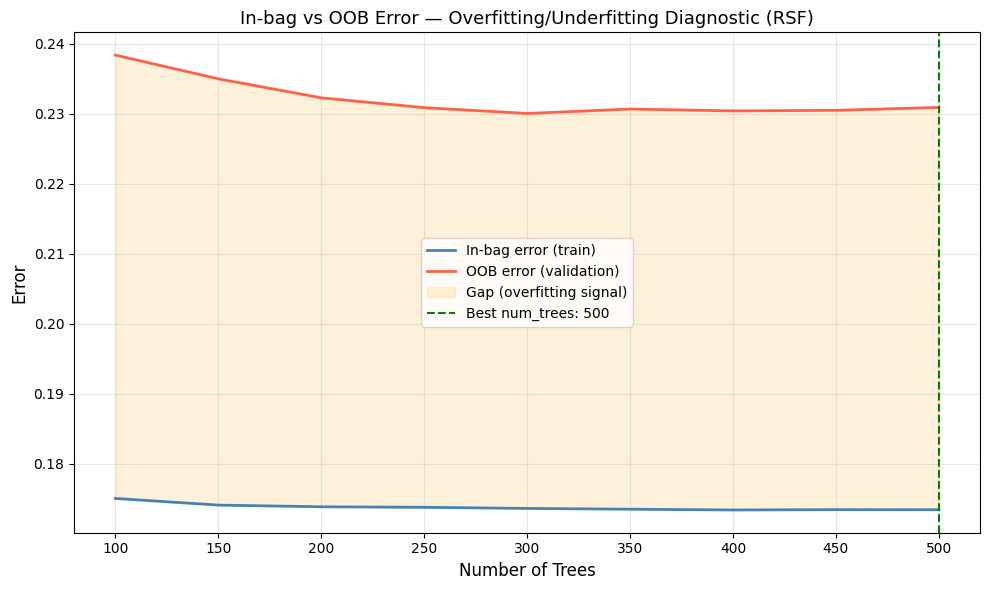

In [ ]:
best_trees_num = random_search.best_params_['model__num_trees']

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(tree_count, train_errors, color="steelblue", linewidth=2, label="In-bag error (train)")
ax.plot(tree_count, oob_errors,   color="tomato",    linewidth=2, label="OOB error (validation)")

ax.fill_between(
    tree_count, train_errors, oob_errors,
    alpha=0.15, color="orange", label="Gap (overfitting signal)"
)
ax.axvline(best_trees_num, color="green", linestyle="--", linewidth=1.5, label=f"Best num_trees: {best_trees_num}")

ax.set_xlabel("Number of Trees", fontsize=12)
ax.set_ylabel("Error", fontsize=12)
ax.set_title("In-bag vs OOB Error — Overfitting/Underfitting Diagnostic (RSF)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_pic(plt, "rsf_oob_inbag_curves.png")
plt.show()

In [ ]:
wandb.log({"curves/rsf_oob_inbag_diagnostic": wandb.Image("figures/rsf_oob_inbag_curves.png")})

# Store best parameters and pipeline

In [ ]:
rsf_best_params

{'min_node_size': 112,
 'mtry': 'sqrt',
 'num_trees': np.int64(500),
 'replace': True,
 'sample_fraction': np.float64(0.7618878104807162)}

In [ ]:
cv_cindex = random_search.best_score_
cv_cindex

np.float64(0.7677330555984344)

In [ ]:
cv_cindex_std = random_search.cv_results_['std_test_score'][random_search.best_index_] 
cv_cindex_std

np.float64(0.022445739751145645)

In [25]:
joblib.dump(rsf_best_params, "joblib-storage/rsf_best_params.joblib")
joblib.dump(random_search.best_estimator_, "joblib-storage/rsf_best_pipeline.joblib")
joblib.dump(cv_cindex, "joblib-storage/rsf_best_cv_cindex.joblib")
joblib.dump(cv_cindex_std, "joblib-storage/rsf_best_cv_cindex_std.joblib")

['joblib-storage/rsf_best_cv_cindex_std.joblib']

In [ ]:
wandb.log({"best_parameters": rsf_best_params})
wandb.finish()

trees/gap,█▆▃▂▁▂▂▂▂
trees/num_trees,▁▂▃▄▅▅▆▇█
trees/oob_error,█▅▃▂▁▂▁▁▂
trees/train_error,█▄▃▃▂▁▁▁▁
trees/gap,0.0575
trees/num_trees,500
trees/oob_error,0.2309
trees/train_error,0.1734
